<div class="alert alert-info">
<h2> Проект модуля. Система поиска подходящих товаров на основе дообученной CLIP модели </h2>



</div>


<font color='red'>

# Загрузка датасета с Kuggle через kagglehub - если потребуется

In [ ]:
%pip install kagglehub

In [ ]:
# Рекомендуемый код, если архивом не "пролезет"
import kagglehub
# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/fashion-product-text-images-dataset")
print("Path to dataset files:", path)

<div class="alert alert-info">
<h2>  </h2>


Импорты необходимых библиотек, первоначальные настройки
</div>


<font color='red'>

In [130]:
# библиотечки
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import seaborn as sns
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# устройство CPU или GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# пути к данным
RAW_DATA_PATH = "raw_dataset/data.csv"
IMAGE_DIR = "raw_dataset/data"


Используемое устройство: cpu


<div class="alert alert-info">
<h2>  </h2>


Загрузка и предобработка датасета
</div>


<font color='red'>

In [131]:
# 1.1: Загрузка и вывод примеров текстов

df = pd.DataFrame() 

# Загрузка CSV файла
df = pd.read_csv(RAW_DATA_PATH)
print(f"Размер датасета: {df.shape}")
print("\nПервые строки датасета:")
df.head()


Размер датасета: (44441, 4)

Первые строки датасета:


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes



Примеры изображений:


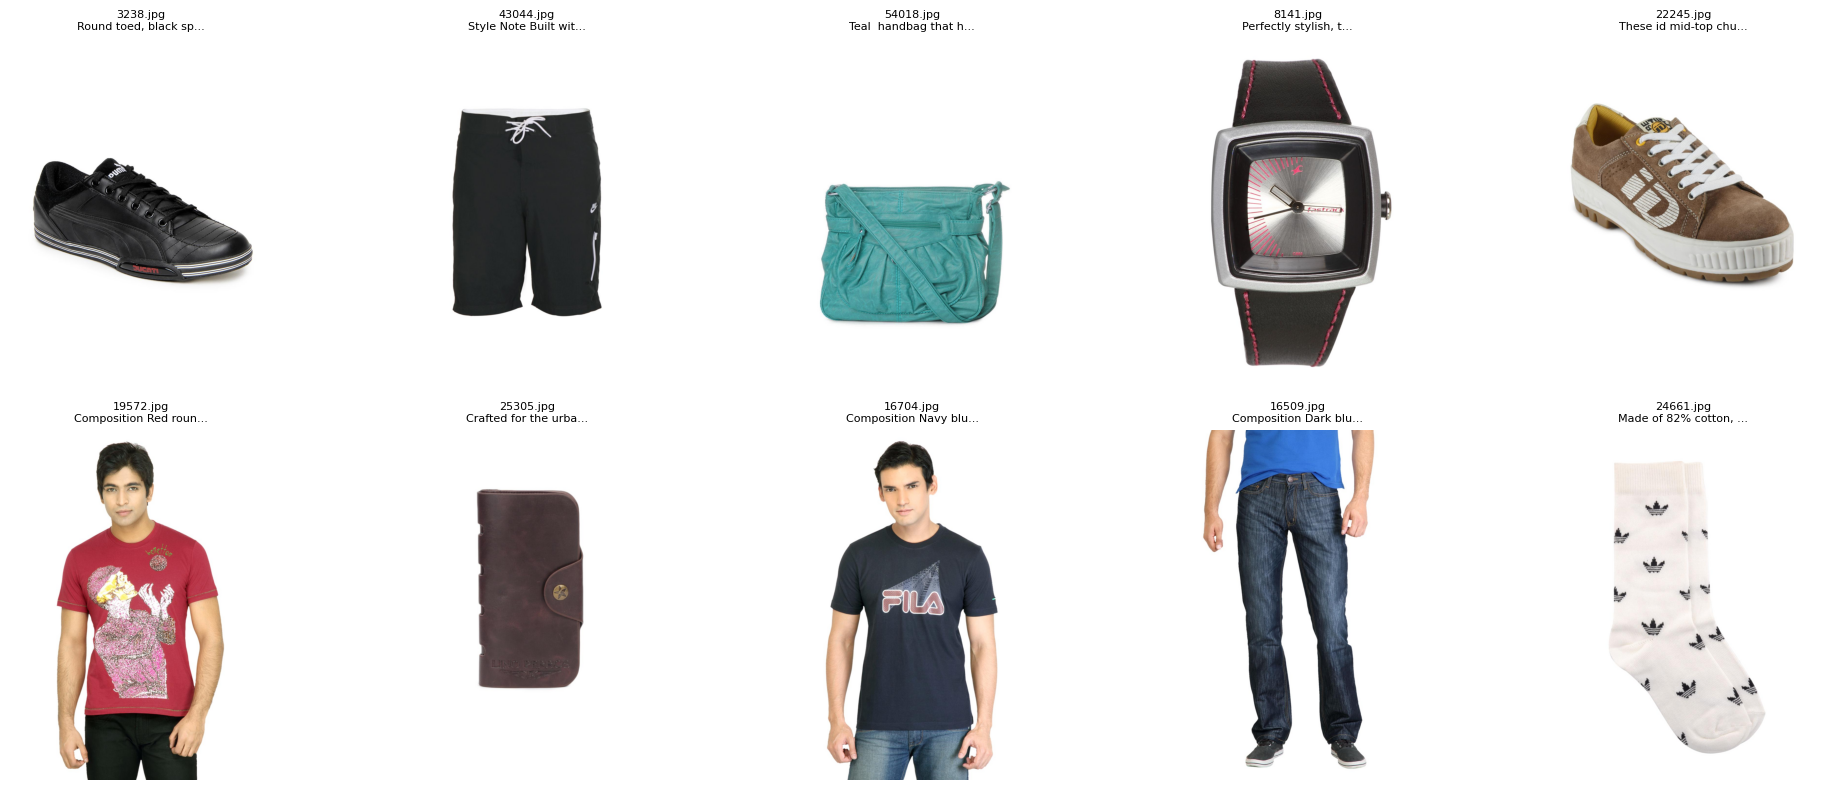

In [132]:
# 1.2: вывод примеров изображений и описаний
def display_samples(df, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx >= num_samples:
            break
            
        img_name = df.iloc[idx]['image']
        img_path = os.path.join(IMAGE_DIR, img_name)
        
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis('off')
            
            # Обрезаем описание для отображения
            description = df.iloc[idx]['description']
            short_desc = description[:20] + "..." if len(description) > 20 else description
            ax.set_title(f"{img_name}\n{short_desc}", fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Отображение 10 примеров
print("\nПримеры изображений:")
display_samples(df)

In [133]:
# 2: Проверка данных

# 2.1. Подсчет количества фотографий в папке
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Количество фотографий в папке: {len(image_files)}")

# 2.2. Проверка, что все фотографии есть в data.csv
images_in_csv = set(df['image'].astype(str).str.strip())
images_in_folder = set(image_files)

missing_in_csv = images_in_folder - images_in_csv
missing_in_folder = images_in_csv - images_in_folder

print(f"\nФотографий в папке, но нет в CSV: {len(missing_in_csv)}")
print(f"Записей в CSV, но нет фотографий: {len(missing_in_folder)}")

if len(missing_in_csv) > 0:
    print("Примеры отсутствующих в CSV:", list(missing_in_csv)[:5])

Количество фотографий в папке: 44441

Фотографий в папке, но нет в CSV: 0
Записей в CSV, но нет фотографий: 0


Количество строк в data.csv: 44441
Количество пустых description: 283


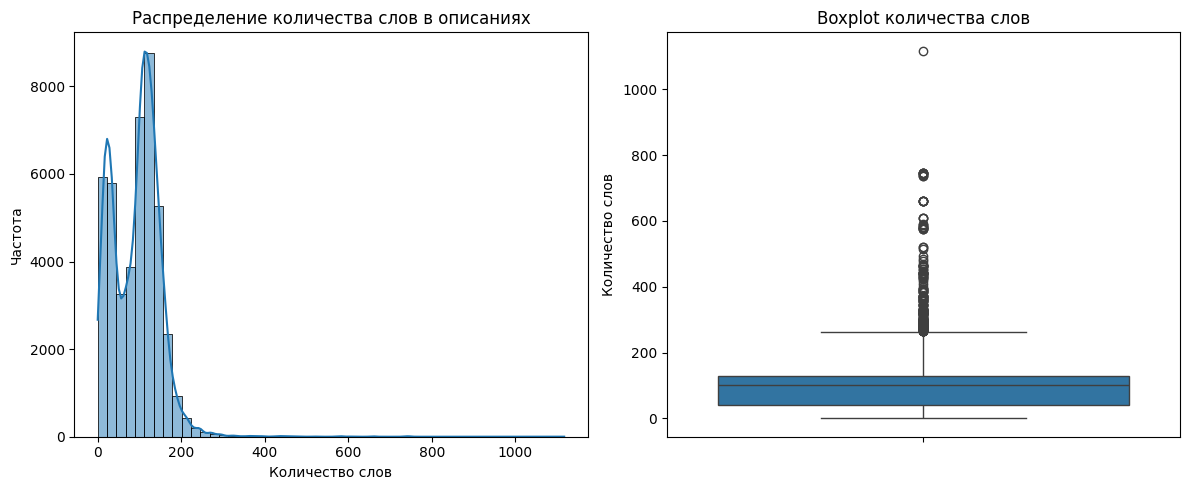


Статистика количества слов:
Минимум: 0
Максимум: 1117
Среднее: 93.16
Медиана: 102.0
Стандартное отклонение: 57.18


In [134]:
# 3.1: Анализ текстовых описаний

# Основная информация о датасете
print(f"Количество строк в data.csv: {len(df)}")

# Проверка пустых описаний
empty_descriptions = df['description'].isna() | (df['description'].astype(str).str.strip() == '')
print(f"Количество пустых description: {empty_descriptions.sum()}")

# Подсчет количества слов в описаниях
df['word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))

# Визуализация распределения слов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Распределение количества слов в описаниях')
plt.xlabel('Количество слов')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['word_count'])
plt.title('Boxplot количества слов')
plt.ylabel('Количество слов')

plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика количества слов:")
print(f"Минимум: {df['word_count'].min()}")
print(f"Максимум: {df['word_count'].max()}")
print(f"Среднее: {df['word_count'].mean():.2f}")
print(f"Медиана: {df['word_count'].median()}")
print(f"Стандартное отклонение: {df['word_count'].std():.2f}")

In [136]:
# 3.2 функция  очистки текста

def clean_text(text):
    """Оставляет только английские символы, цифры и установленные символы"""
    if not isinstance(text, str):
        return ""
    
    # Удаляем специальные символы, оставляем только английские буквы, цифры, знаки .,-
    cleaned = re.sub(r'[^a-zA-Z0-9\s.,%-]', '', text)
    
    # Переводим все символы в нижний регистр
    cleaned = cleaned.lower()
    
    # Удаляем лишние пробелы
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    return cleaned

In [137]:
#  3.3: Полная замена дублированных описаний в description

print("\n" + "="*80)
print("ПОЛНАЯ ЗАМЕНА ДУБЛИРОВАННЫХ ОПИСАНИЙ:")
print("="*80)

# Находим все дубликаты в поле description (ВКЛЮЧАЯ первое вхождение)
duplicate_mask_all = df.duplicated(subset=['description'], keep=False)
duplicate_indices_all = df[duplicate_mask_all].index.tolist()
duplicate_count_all = len(duplicate_indices_all)

print(f"Найдено строк с дублированными описаниями: {duplicate_count_all}")

if duplicate_count_all > 0:
    # Группируем дубликаты по значению description (ВСЕ строки в группе)
    duplicate_groups = {}
    for idx in duplicate_indices_all:
        desc = df.loc[idx, 'description']
        if desc not in duplicate_groups:
            # Находим ВСЕ индексы с этим описанием
            all_indices = df[df['description'] == desc].index.tolist()
            duplicate_groups[desc] = all_indices
    
    print(f"\nУникальных дублирующихся описаний: {len(duplicate_groups)}")
    
    # Выводим статистику по группам дубликатов
    print("\nРаспределение дубликатов (ВКЛЮЧАЯ первые вхождения):")
    for desc, indices in list(duplicate_groups.items())[:10]:
        print(f"  Группа из {len(indices)} строк: '{desc[:50]}{'...' if len(desc) > 50 else ''}'")
    
    if len(duplicate_groups) > 10:
        print(f"  ... и еще {len(duplicate_groups) - 10} групп")
    
    print("\n" + "-"*80)
    print("ПРОЦЕСС ЗАМЕНЫ ДУБЛИРОВАННЫХ ОПИСАНИЙ:")
    print("-"*80)
    
    # Сохраняем оригинальные описания для отчета
    df['description_original'] = df['description'].copy()
    
    # Заменяем ВСЕ строки в каждой группе дубликатов
    total_replaced = 0
    modified_descriptions = []
    
    for desc, indices in duplicate_groups.items():
        if len(indices) > 1:  # Если есть дубликаты
            for idx in indices:  # Обрабатываем ВСЕ строки в группе, включая первую
                # Получаем текущее описание
                current_desc = df.loc[idx, 'description']
                
                # Получаем значения из полей category и display name
                category = str(df.loc[idx, 'category']) if 'category' in df.columns else ''
                display_name = str(df.loc[idx, 'display name']) if 'display name' in df.columns else ''
                
                # Очищаем значения
                category_clean = category.strip() if category and category.lower() not in ['nan', 'none', 'null', 'n/a', '', '-'] else ''
                display_name_clean = display_name.strip() if display_name and display_name.lower() not in ['nan', 'none', 'null', 'n/a', '', '-'] else ''
                
                # Формируем НОВОЕ описание: category + display name
                new_parts = []
                if category_clean:
                    new_parts.append(category_clean)
                if display_name_clean:
                    new_parts.append(display_name_clean)
                
                # Если оба поля пустые, оставляем текущее описание
                if not new_parts:
                    new_desc = current_desc
                else:
                    new_desc = ' '.join(new_parts)
                
                # Обновляем описание (даже если не изменилось)
                df.loc[idx, 'description'] = new_desc
                total_replaced += 1
                
                # Сохраняем информацию об изменении
                if current_desc != new_desc:
                    modified_descriptions.append({
                        'index': idx,
                        'original': current_desc,
                        'new': new_desc,
                        'category': category_clean,
                        'display_name': display_name_clean,
                        'is_first_in_group': idx == indices[0]  # Первая ли это строка в группе
                        })
    
    print(f"\nОбработано строк в группах дубликатов: {total_replaced}")
    print(f"Из них реально изменено: {len(modified_descriptions)}")
    
    # Выводим примеры замен
    if modified_descriptions:
        print("\nПримеры замененных описаний:")
        print("-"*80)
        
        # Показываем по 2 примера из каждой группы
        shown_groups = set()
        examples_shown = 0
        
        for mod in modified_descriptions:
            # Находим группу для этого описания
            desc_group = duplicate_groups.get(mod['original'], [])
            group_id = mod['original']
            
            if group_id not in shown_groups and examples_shown < 10:
                shown_groups.add(group_id)
                examples_shown += 1
                
                print(f"\nПример {examples_shown} (Группа из {len(desc_group)} строк):")
                print(f"  Оригинальное описание: '{mod['original'][:80]}{'...' if len(mod['original']) > 80 else ''}'")
                
                # Показываем первую и одну из последующих строк
                first_idx = desc_group[0]
                other_idx = desc_group[1] if len(desc_group) > 1 else None
                
                print(f"  Строка {first_idx} (первая в группе):")
                print(f"    Было: '{df.loc[first_idx, 'description_original']}'")
                print(f"    Стало: '{df.loc[first_idx, 'description']}'")
                
                if other_idx:
                    print(f"  Строка {other_idx} (одна из дубликатов):")
                    print(f"    Было: '{df.loc[other_idx, 'description_original']}'")
                    print(f"    Стало: '{df.loc[other_idx, 'description']}'")
        
        if len(modified_descriptions) > examples_shown * 2:
            print(f"\n... и еще {len(modified_descriptions) - examples_shown * 2} изменений")
    
    # Проверяем результат
    print("\n" + "-"*80)
    print("ПРОВЕРКА РЕЗУЛЬТАТА:")
    print("-"*80)
    
    # Находим дубликаты после замены
    new_duplicate_mask = df.duplicated(subset=['description'], keep=False)
    new_duplicate_count = new_duplicate_mask.sum()
    
    print(f"Дубликатов до замены: {duplicate_count_all} строк")
    print(f"Дубликатов после замены: {new_duplicate_count} строк")
    print(f"Устранено дубликатов: {duplicate_count_all - new_duplicate_count} строк")
    
    # Если остались дубликаты, показываем их
    if new_duplicate_count > 0:
        print(f"\nОстались следующие дубликаты после замены:")
        new_duplicate_groups = {}
        for idx in df[new_duplicate_mask].index:
            desc = df.loc[idx, 'description']
            if desc not in new_duplicate_groups:
                new_duplicate_groups[desc] = []
            new_duplicate_groups[desc].append(idx)
        
        for i, (desc, indices) in enumerate(list(new_duplicate_groups.items())[:5], 1):
            print(f"\n  Группа {i} ({len(indices)} строк):")
            print(f"  Описание: '{desc[:80]}{'...' if len(desc) > 80 else ''}'")
            print(f"  Индексы: {indices}")
    
    print("\n" + "="*80)
    print("ЗАМЕНА ДУБЛИРОВАННЫХ ОПИСАНИЙ ЗАВЕРШЕНА")
    print("="*80)
    
else:
    print("\nДубликатов в поле 'description' не найдено.")
    print("Замена не требуется.")

# Обновляем word_count после замены дублированных описаний
df['word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))
print(f"Обновлено поле word_count после замены дубликатов")

# Дополнительная статистика
print("\n" + "="*80)
print("ФИНАЛЬНАЯ СТАТИСТИКА:")
print("="*80)
print(f"Всего строк в датафрейме: {len(df)}")
print(f"Уникальных описаний до замены: {df['description_original'].nunique()}")
print(f"Уникальных описаний после замены: {df['description'].nunique()}")

# удаляем временную колонку
# df = df.drop(columns=['description_original'])


ПОЛНАЯ ЗАМЕНА ДУБЛИРОВАННЫХ ОПИСАНИЙ:
Найдено строк с дублированными описаниями: 7888

Уникальных дублирующихся описаний: 2304

Распределение дубликатов (ВКЛЮЧАЯ первые вхождения):
  Группа из 3 строк: 'These id mid-top chukka shoes add a fresh spin on ...'
  Группа из 2 строк: 'Why not add some pop to your bag collection with t...'
  Группа из 6 строк: 'Specialising in fashionable style, and crafted by ...'
  Группа из 934 строк: '-'
  Группа из 4 строк: 'With Vitamin E and anti-aging properties, time plu...'
  Группа из 3 строк: ' Style Note'
  Группа из 3 строк: 'Revel in the comfort of pure leather and look styl...'
  Группа из 2 строк: 'Round toed sports shoes with central lace fastenin...'
  Группа из 16 строк: 'Lakme Absolute Matte lipstick, luxurious rich colo...'
  Группа из 22 строк: 'Wash care Machine wash separately using mild deter...'
  ... и еще 2294 групп

--------------------------------------------------------------------------------
ПРОЦЕСС ЗАМЕНЫ ДУБЛИРОВАННЫХ ОПИС

In [138]:
# 3.4: Замена коротких пустых и не информативных описаний 

print("Замена коротких описаний на category + display name...")

# Определяем, какие строки нужно заменить
def need_replacement(desc, word_count):
    if not isinstance(desc, str):
        return True
    desc = desc.strip().lower()
    
    # Если описание уже состоит из category + display name (проверяем по наличию двух слов из этих полей)
    # Это эвристика - если описание содержит меньше 5 слов, но это явно не пустое значение
    if word_count < 5:
        # Проверяем, не является ли это уже улучшенным описанием
        if desc in ['', '-', 'nan', 'n/a', 'none', 'null']:
            return True
        
    return word_count < 5

# Находим строки для замены
replace_mask = df.apply(lambda row: need_replacement(row['description'], row['word_count']), axis=1)
replace_count = replace_mask.sum()

if replace_count > 0:
    print(f"Найдено строк для замены: {replace_count}")
    
    # Функция замены
    def replace_desc(row):
        cat = str(row.get('category', '')).strip()
        disp = str(row.get('display name', '')).strip()
        
        # Проверяем на невалидные значения
        cat = '' if cat.lower() in ['nan', 'n/a', 'none', 'null', '', '-'] else cat
        disp = '' if disp.lower() in ['nan', 'n/a', 'none', 'null', '', '-'] else disp
        
        # Формируем новое описание
        parts = []
        if cat: parts.append(cat)
        if disp: parts.append(disp)
        
        return ' '.join(parts) if parts else row['description']
    
    # Применяем замену
    df.loc[replace_mask, 'description'] = df[replace_mask].apply(replace_desc, axis=1)
    
    # Обновляем word_count
    df['word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))
    
    print(f"Заменено {replace_count} описаний")
    print(f"Теперь коротких описаний (< 5 слов): {(df['word_count'] < 5).sum()}")
else:
    print("Коротких описаний не найдено")

Замена коротких описаний на category + display name...
Найдено строк для замены: 402
Заменено 402 описаний
Теперь коротких описаний (< 5 слов): 112


In [139]:
# 4: Очистка текста

df['description_cleaned'] = df['description'].apply(clean_text)


In [140]:
# 5: Удаление дубликатов по очищенному описанию

print("\n" + "="*80)
print("УДАЛЕНИЕ ДУБЛИКАТОВ ПО ОЧИЩЕННОМУ ОПИСАНИЮ:")
print("="*80)

# Сохраняем размер до удаления
initial_size = len(df)

# Обновляем description_cleaned с учетом всех изменений
df['description_cleaned'] = df['description'].apply(clean_text)

# Находим и удаляем дубликаты по очищенному описанию
dup_cleaned = df.duplicated(subset=['description_cleaned'], keep='first').sum()
print(f"Найдено дубликатов в 'description_cleaned': {dup_cleaned}")

if dup_cleaned > 0:
    print("\nПримеры дубликатов для удаления:")
    print("-" * 80)
    
    dup_mask = df.duplicated(subset=['description_cleaned'], keep='first')
    duplicate_groups = df[dup_mask].groupby('description_cleaned')
    
    for i, (desc, group) in enumerate(list(duplicate_groups)[:5], 1):
        indices = group.index.tolist()
        print(f"\nПример {i}:")
        print(f"  Текст: '{desc[:80]}{'...' if len(desc) > 80 else ''}'")
        print(f"  Количество дубликатов: {len(indices)}")
        print(f"  Индексы для удаления: {indices}")
    
    # Удаляем дубликаты
    df = df.drop_duplicates(subset=['description_cleaned'], keep='first')
    print(f"\nУдалено {dup_cleaned} дубликатов")
else:
    print("Дубликатов не найдено")

# Итоговая статистика
final_size = len(df)
print("\n" + "="*80)
print("ИТОГОВАЯ СТАТИСТИКА:")
print("="*80)
print(f"Начальный размер: {initial_size} строк")
print(f"Финальный размер: {final_size} строк")
print(f"Удалено: {initial_size - final_size} строк")
print(f"Уникальных описаний (description): {df['description'].nunique()}")
print(f"Уникальных описаний (description_cleaned): {df['description_cleaned'].nunique()}")


УДАЛЕНИЕ ДУБЛИКАТОВ ПО ОЧИЩЕННОМУ ОПИСАНИЮ:
Найдено дубликатов в 'description_cleaned': 2647

Примеры дубликатов для удаления:
--------------------------------------------------------------------------------

Пример 1:
  Текст: '1. composition is 52% cotton and 48% polyester the trendy striped polo t-shirt i...'
  Количество дубликатов: 1
  Индексы для удаления: [39336]

Пример 2:
  Текст: '1. perfect for running purpose 2. outsole designed for better grip on the road 3...'
  Количество дубликатов: 1
  Индексы для удаления: [42864]

Пример 3:
  Текст: '1. stretch underarm panel and flat seams provide freedom of movement 2. syntheti...'
  Количество дубликатов: 1
  Индексы для удаления: [36587]

Пример 4:
  Текст: '1. strongly made body with an attached cap 2. durable and handy 3. lightweight 4...'
  Количество дубликатов: 1
  Индексы для удаления: [43167]

Пример 5:
  Текст: 'a belt is an essential detail to complete your ensemble and this belt from baggi...'
  Количество дубликатов: 

In [141]:
# 6.1:  финальная проверка данных

# Подсчет количества фотографий в папке
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
print(f"Количество фотографий в папке: {len(image_files)}")

# Проверка, что все фотографии есть в data.csv
images_in_csv = set(df['image'].astype(str).str.strip())
images_in_folder = set(image_files)

missing_in_csv = images_in_folder - images_in_csv
missing_in_folder = images_in_csv - images_in_folder

print(f"\nФотографий в папке, но нет в CSV: {len(missing_in_csv)}")
print(f"Записей в CSV, но нет фотографий: {len(missing_in_folder)}")

if len(missing_in_csv) > 0:
    print("Примеры отсутствующих в CSV:", list(missing_in_csv)[:5])

Количество фотографий в папке: 44441

Фотографий в папке, но нет в CSV: 2647
Записей в CSV, но нет фотографий: 0
Примеры отсутствующих в CSV: ['52060.jpg', '9716.jpg', '53332.jpg', '26601.jpg', '57447.jpg']


Количество строк в data.csv: 41794
Количество пустых description: 0


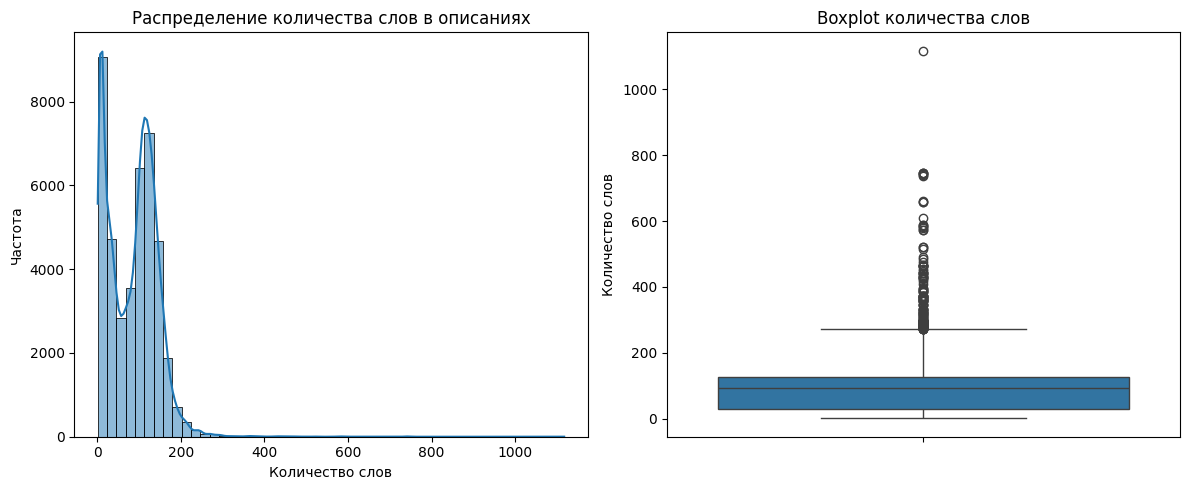


Статистика количества слов:
Минимум: 1
Максимум: 1117
Среднее: 85.08
Медиана: 94.0
Стандартное отклонение: 58.68


In [142]:
# 6.2: финальный анализ текстовых описаний

# Основная информация о датасете
print(f"Количество строк в data.csv: {len(df)}")

# Проверка пустых описаний
empty_descriptions = df['description'].isna() | (df['description'].astype(str).str.strip() == '')
print(f"Количество пустых description: {empty_descriptions.sum()}")

# Подсчет количества слов в описаниях
df['word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))

# Визуализация распределения слов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Распределение количества слов в описаниях')
plt.xlabel('Количество слов')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['word_count'])
plt.title('Boxplot количества слов')
plt.ylabel('Количество слов')

plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика количества слов:")
print(f"Минимум: {df['word_count'].min()}")
print(f"Максимум: {df['word_count'].max()}")
print(f"Среднее: {df['word_count'].mean():.2f}")
print(f"Медиана: {df['word_count'].median()}")
print(f"Стандартное отклонение: {df['word_count'].std():.2f}")

<div class="alert alert-info">
<h2>  Выводы по анализу данных</h2>

Качество описаний в descripton не на высоте. Чтобы улучшить качество датасета и при этом удалить минимальное количество строк из-за прямых дублей, изменил description в проблемных строках на category + display name. Влияние - порядка четверти датасета. Дополнительно почистил текст описаний. 

Есть вероятность, что и с учетом этого целевую метрику не получится достигнуть. Тогда надо будет искать другой способ удаления дублей, очистки и преобразования данных, с использованием соответствующих нейронок.

Очень трудоемкий и муторный процесс.

</div>


<font color='red'>

<div class="alert alert-info">
<h2>  </h2>


Разделение данных на train и test. Реализация кастомного класса датасета
</div>


<font color='red'>

In [143]:
#  7: Разделение данных на train и test

# Сначала фильтруем записи, для которых есть изображения
df['image_exists'] = df['image'].apply(lambda x: os.path.exists(os.path.join(IMAGE_DIR, str(x))))
df = df[df['image_exists']]

print(f"Записей с существующими изображениями: {len(df)}")

# Разделяем данные
train_df, test_df = train_test_split(
    df, 
    test_size=0.1, 
    random_state=42,
    stratify=pd.qcut(df['word_count'], q=10, duplicates='drop') if len(df) > 100 else None
)

print(f"Размер тренировочного набора: {len(train_df)}")
print(f"Размер тестового набора: {len(test_df)}")

# Сохраняем разделенные данные
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

Записей с существующими изображениями: 41794
Размер тренировочного набора: 37614
Размер тестового набора: 4180


In [145]:
# 8: Реализация кастомного класса датасета

class ClothingDataset(Dataset):
    """Кастомный датасет для загрузки изображений и текстовых описаний одежды"""
    
    def __init__(self, dataframe, image_dir, processor, max_length=77):
        """
        Args:
            dataframe: DataFrame с колонками 'image' и 'description_cleaned'
            image_dir: путь к папке с изображениями
            processor: CLIPProcessor для обработки изображений и текста
            max_length: максимальная длина текста
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.processor = processor
        self.max_length = max_length
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        try:
            # Получаем данные
            row = self.dataframe.iloc[idx]
            image_path = os.path.join(self.image_dir, str(row['image']))
            text = str(row['description_cleaned'])
            
            # Загружаем изображение
            image = Image.open(image_path).convert('RGB')
            
            # Обрабатываем с помощью CLIP processor
            inputs = self.processor(
                text=[text],
                images=image,
                return_tensors="pt",
                padding="max_length",
                max_length=self.max_length,
                truncation=True
            )
            
            # Извлекаем tensors
            pixel_values = inputs['pixel_values'].squeeze(0)
            input_ids = inputs['input_ids'].squeeze(0)
            attention_mask = inputs['attention_mask'].squeeze(0)
            
            return {
                'pixel_values': pixel_values,
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'image_path': image_path,
                'text': text
            }
            
        except Exception as e:
            # В случае ошибки возвращаем нулевые данные
            print(f"Ошибка при загрузке элемента {idx}: {e}")
            return self.__getitem__((idx + 1) % len(self))  # Возвращаем следующий элемент
        
# Тестируем датасет
#from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
test_dataset = ClothingDataset(train_df.head(10), IMAGE_DIR, processor)

# Проверяем один элемент
sample = test_dataset[0]
print(f"Ключи в батче: {sample.keys()}")
print(f"Размер pixel_values: {sample['pixel_values'].shape}")
print(f"Размер input_ids: {sample['input_ids'].shape}")
print(f"Текст: {sample['text'][:50]}...")

Ключи в батче: dict_keys(['pixel_values', 'input_ids', 'attention_mask', 'image_path', 'text'])
Размер pixel_values: torch.Size([3, 224, 224])
Размер input_ids: torch.Size([77])
Текст: yellow printed kurta has a mandarin collar with an...


<div class="alert alert-info">
<h2>  </h2>

Подготовка и fine-tune openai/clip-vit-base-patch32
</div>

<font color='red'>

In [146]:
# 9: Загрузка предобученной модели CLIP

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Перемещаем модель на устройство (GPU когда доступно)
model = model.to(device)
print(f"Модель загружена и перемещена на {device}")

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Модель загружена и перемещена на cpu


In [148]:
# 10: Тестовый прогон 10 примеров

def calculate_clip_score(model, processor, images, texts, max_length=77):
    """Вычисляет CLIP score между изображениями и текстами"""
    with torch.no_grad():
        # Обрабатываем входные данные
        inputs = processor(
            text=texts, 
            images=images, 
            return_tensors="pt", 
            padding=True,
            truncation=True,
            max_length=max_length
        )
        
        # Перемещаем на устройство
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Получаем embeddings
        outputs = model(**inputs)
        
        # Вычисляем cosine similarity
        logits_per_image = outputs.logits_per_image  # [batch_size, batch_size]
        logits_per_text = outputs.logits_per_text    # [batch_size, batch_size]
        
        # Берем диагональ (соответствующие пары изображение-текст)
        clip_scores = torch.diag(logits_per_image)
        
    return clip_scores.cpu().numpy()

# Подготовка тестовых данных
test_samples = 10
test_images = []
test_texts = []

for i in range(test_samples):
    row = train_df.iloc[i]
    img_path = os.path.join(IMAGE_DIR, row['image'])
    image = Image.open(img_path).convert('RGB')
    test_images.append(image)
    test_texts.append(row['description_cleaned'])

# Вычисляем CLIP scores
clip_scores = calculate_clip_score(model, processor, test_images, test_texts, max_length=77)

# Выводим результаты
print("CLIP scores для 10 тестовых примеров:")
for i, (text, score) in enumerate(zip(test_texts, clip_scores)):
    print(f"\n{i+1}. Текст: {text[:50]}...")
    print(f"   CLIP score: {score:.4f}")

print(f"\nСредний CLIP score: {np.mean(clip_scores):.4f}")
print(f"Минимальный CLIP score: {np.min(clip_scores):.4f}")
print(f"Максимальный CLIP score: {np.max(clip_scores):.4f}")

CLIP scores для 10 тестовых примеров:

1. Текст: yellow printed kurta has a mandarin collar with an...
   CLIP score: 36.2607

2. Текст: lens colour purple lens type lens with uv protecti...
   CLIP score: 30.1726

3. Текст: blue woven dress, mandarin collar, yoke in front, ...
   CLIP score: 30.2954

4. Текст: green handbag that has panels of faux croc print f...
   CLIP score: 31.7255

5. Текст: brown floral printed sling bag with sequin embelli...
   CLIP score: 33.2962

6. Текст: nail polish colorbar crystal calm nail lacquer 70...
   CLIP score: 31.6186

7. Текст: tshirts adidas men one love black t-shirt...
   CLIP score: 27.0812

8. Текст: its all about walking and running healthy with the...
   CLIP score: 29.1365

9. Текст: the accords are top notes of the new edition adida...
   CLIP score: 27.7569

10. Текст: composition black and white sweatshirt made of 100...
   CLIP score: 26.7407

Средний CLIP score: 30.4084
Минимальный CLIP score: 26.7407
Максимальный CLIP score: 36.26

In [152]:
# 11: Подготовка данных для обучения

# Создаем датасеты
train_dataset = ClothingDataset(train_df, IMAGE_DIR, processor)
test_dataset = ClothingDataset(test_df, IMAGE_DIR, processor)

# Создаем DataLoader
batch_size = 16  # Можно увеличить при использовании GPU

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Размер train dataloader: {len(train_dataloader)} батчей")
print(f"Размер test dataloader: {len(test_dataloader)} батчей")

Размер train dataloader: 2351 батчей
Размер test dataloader: 262 батчей


In [162]:
# 12: Реализация цикла обучения

def train_epoch(model, dataloader, optimizer, device, temperature=0.07, accumulation_steps=2):
    """Одна эпоха обучения с temperature scaling"""
    model.train()
    total_loss = 0
    total_clip_score = 0
    num_batches = 0
    
    optimizer.zero_grad()
    
    for batch_idx, batch in enumerate(dataloader):
        # Перемещаем данные на устройство
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Получаем features
        text_features = model.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        image_features = model.get_image_features(pixel_values=pixel_values)
        
        # Нормализуем
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        
        # Вычисляем similarity БЕЗ temperature (для CLIP Score)
        similarity_matrix = image_features @ text_features.t()
        
        # Вычисляем similarity С temperature (для loss)
        logits_per_image = similarity_matrix / temperature
        logits_per_text = logits_per_image.t()
        
        # Контрастный loss (с temperature)
        labels = torch.arange(logits_per_image.size(0)).to(device)
        loss_img = nn.CrossEntropyLoss()(logits_per_image, labels)
        loss_txt = nn.CrossEntropyLoss()(logits_per_text, labels)
        loss = (loss_img + loss_txt) / 2
        
        # Масштабируем loss для gradient accumulation
        loss = loss / accumulation_steps
        
        # Обратный проход
        loss.backward()
        
        # Вычисляем CLIP score для батча (БЕЗ temperature!)
        with torch.no_grad():
            clip_scores = torch.diag(similarity_matrix)  # ← БЕЗ temperature!
            batch_clip_score = clip_scores.mean().item()
        
        # Обновляем веса через accumulation_steps шагов
        if (batch_idx + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        total_clip_score += batch_clip_score
        num_batches += 1
        
        # Логирование
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx + 1}/{len(dataloader)}: "
                  f"Loss = {loss.item() * accumulation_steps:.4f}, "
                  f"CLIP Score = {batch_clip_score:.4f}")
    
    return total_loss / num_batches, total_clip_score / num_batches

def validate(model, dataloader, device):
    """Валидация модели"""
    model.eval()
    total_clip_score = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch in dataloader:
            # Перемещаем данные на устройство
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Получаем эмбеддинги
            text_features = model.get_text_features(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            image_features = model.get_image_features(pixel_values=pixel_values)
            
            # Нормализуем
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
            # Вычисляем cosine similarity (БЕЗ temperature!)
            similarity_matrix = image_features @ text_features.t()
            clip_scores = torch.diag(similarity_matrix)  # ← БЕЗ temperature!
            
            total_clip_score += clip_scores.mean().item()
            num_batches += 1
    
    return total_clip_score / num_batches


# Функция для обучения модели
def train_model(model, train_dataloader, val_dataloader, num_epochs=3, learning_rate=5e-5):
    """Основная функция обучения"""
    # Подготовка оптимизатора
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    
    # Списки для хранения метрик
    train_losses = []
    train_scores = []
    val_scores = []
    
    # Папка для сохранения чекпоинтов
    os.makedirs('checkpoints', exist_ok=True)
    
    for epoch in range(num_epochs):
        print(f"\n{'='*50}")
        print(f"Эпоха {epoch + 1}/{num_epochs}")
        print(f"{'='*50}")
        
        # Обучение
        print("Обучение...")
        train_loss, train_clip_score = train_epoch(
            model, train_dataloader, optimizer, device
        )
        
        # Валидация
        print("\nВалидация...")
        val_clip_score = validate(model, val_dataloader, device)
        
        # Сохраняем метрики
        train_losses.append(train_loss)
        train_scores.append(train_clip_score)
        val_scores.append(val_clip_score)
        
        # Выводим результаты эпохи
        print(f"\nРезультаты эпохи {epoch + 1}:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Train CLIP Score: {train_clip_score:.4f}")
        print(f"  Val CLIP Score: {val_clip_score:.4f}")
        
        # Сохраняем чекпоинт
        checkpoint_path = f"checkpoints/clip_epoch_{epoch + 1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_clip_score': train_clip_score,
            'val_clip_score': val_clip_score,
        }, checkpoint_path)
        
        print(f"Чекпоинт сохранен: {checkpoint_path}")
    
    return train_losses, train_scores, val_scores

In [163]:
# 13: Запуск обучения

# Запускаем обучение
num_epochs = 3  # Можно увеличить для лучших результатов
train_losses, train_scores, val_scores = train_model(
    model, 
    train_dataloader, 
    test_dataloader,  # Используем test как validation
    num_epochs=num_epochs,
    learning_rate=1e-5
)


Эпоха 1/3
Обучение...
  Batch 50/2351: Loss = 0.6482, CLIP Score = 0.8695
  Batch 100/2351: Loss = 0.5040, CLIP Score = 0.8599
  Batch 150/2351: Loss = 0.9574, CLIP Score = 0.8224
  Batch 200/2351: Loss = 0.3941, CLIP Score = 0.8590
  Batch 250/2351: Loss = 0.6174, CLIP Score = 0.8423
  Batch 300/2351: Loss = 0.3724, CLIP Score = 0.8719
  Batch 350/2351: Loss = 0.4235, CLIP Score = 0.8492
  Batch 400/2351: Loss = 0.2758, CLIP Score = 0.8673
  Batch 450/2351: Loss = 0.4677, CLIP Score = 0.8475
  Batch 500/2351: Loss = 0.1826, CLIP Score = 0.8620
  Batch 550/2351: Loss = 0.3066, CLIP Score = 0.8606
  Batch 600/2351: Loss = 0.5882, CLIP Score = 0.8303
  Batch 650/2351: Loss = 0.2863, CLIP Score = 0.8561
  Batch 700/2351: Loss = 0.1084, CLIP Score = 0.8467
  Batch 750/2351: Loss = 0.2915, CLIP Score = 0.8899
  Batch 800/2351: Loss = 0.1785, CLIP Score = 0.8311
  Batch 850/2351: Loss = 0.1996, CLIP Score = 0.8436
  Batch 900/2351: Loss = 0.2618, CLIP Score = 0.8538
  Batch 950/2351: Loss =

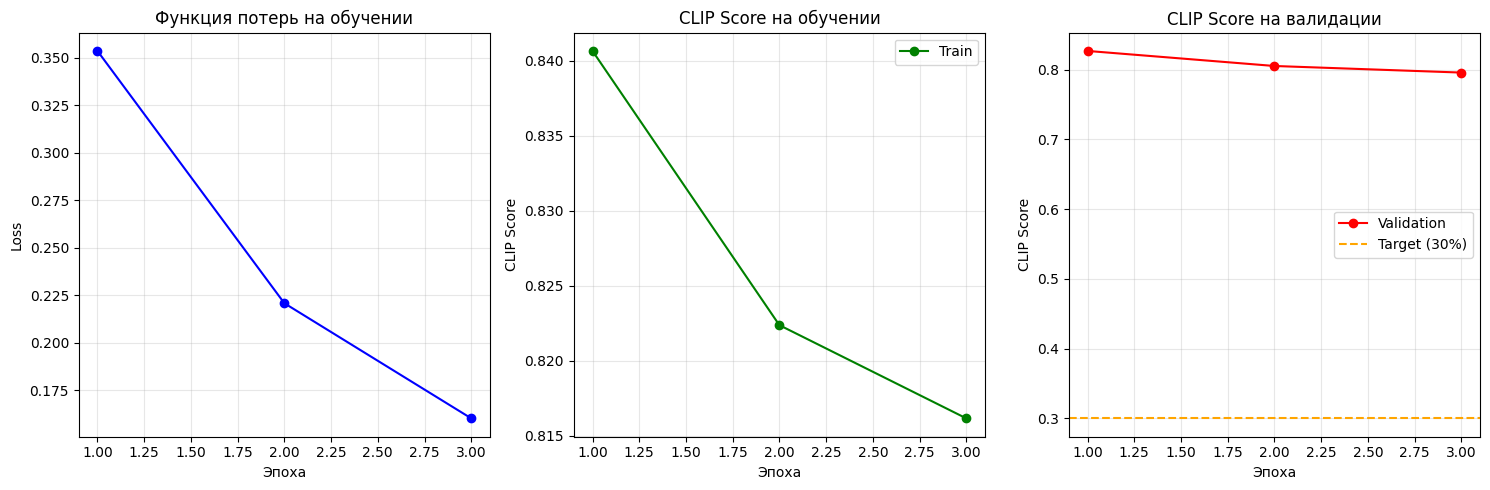

Финальный CLIP score на валидации: 0.7957
✅ Целевое значение достигнуто (>= 30%)


In [164]:
# 14: Визуализация результатов обучения

plt.figure(figsize=(15, 5))

# График loss
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', marker='o')
plt.title('Функция потерь на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# График CLIP score на обучении
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_scores) + 1), train_scores, 'g-', marker='o', label='Train')
plt.title('CLIP Score на обучении')
plt.xlabel('Эпоха')
plt.ylabel('CLIP Score')
plt.grid(True, alpha=0.3)
plt.legend()

# График CLIP score на валидации
plt.subplot(1, 3, 3)
plt.plot(range(1, len(val_scores) + 1), val_scores, 'r-', marker='o', label='Validation')
plt.title('CLIP Score на валидации')
plt.xlabel('Эпоха')
plt.ylabel('CLIP Score')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.3, color='orange', linestyle='--', label='Target (30%)')
plt.legend()

plt.tight_layout()
plt.show()

# Проверяем целевое значение
print(f"Финальный CLIP score на валидации: {val_scores[-1]:.4f}")
if val_scores[-1] >= 0.3:
    print("✅ Целевое значение достигнуто (>= 30%)")
else:
    print("❌ Целевое значение не достигнуто")

<div class="alert alert-info">
<h2> Система поиска подходящих товаров </h2>


Векторное представление данных 
</div>


<font color='red'>

In [165]:
# 15: Загрузка чекпоинта дообученной модели

def load_finetuned_model(checkpoint_path):
    """Загружает дообученную модель из чекпоинта"""
    # Загружаем базовую модель
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    # Загружаем веса из чекпоинта
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Перемещаем модель на устройство
    model = model.to(device)
    model.eval()
    
    print(f"Модель загружена из {checkpoint_path}")
    print(f"CLIP Score чекпоинта: {checkpoint['val_clip_score']:.4f}")
    
    return model, processor

# Загружаем лучшую модель (последнюю эпоху или с лучшим val score)
#checkpoint_path = f"checkpoints/clip_epoch_{num_epochs}.pt"
checkpoint_path = f"checkpoints/clip_epoch_1.pt" # берем так как лучшая метрика на валидации
model, processor = load_finetuned_model(checkpoint_path)

Модель загружена из checkpoints/clip_epoch_1.pt
CLIP Score чекпоинта: 0.8267


In [167]:
# 16: Предварительное вычисление эмбеддингов изображений

def compute_image_embeddings(model, dataframe, image_dir, processor, batch_size=32):
    """Вычисляет и сохраняет эмбеддинги всех изображений"""
    embeddings_path = "image_embeddings.pt"
    image_paths_path = "image_paths.pkl"
    descriptions_path = "descriptions.pkl"
    
    # Проверяем, существуют ли уже вычисленные эмбеддинги
    if os.path.exists(embeddings_path) and os.path.exists(image_paths_path):
        print("Загрузка предварительно вычисленных эмбеддингов...")
        image_embeddings = torch.load(embeddings_path, map_location=device)
        image_paths = pd.read_pickle(image_paths_path)
        descriptions = pd.read_pickle(descriptions_path)
        return image_embeddings, image_paths, descriptions
    
    print("Вычисление эмбеддингов изображений...")
    
    # Подготовка DataLoader для эффективной обработки
    class EmbeddingDataset(Dataset):
        def __init__(self, dataframe, image_dir):
            self.dataframe = dataframe.reset_index(drop=True)
            self.image_dir = image_dir
            
        def __len__(self):
            return len(self.dataframe)
        
        def __getitem__(self, idx):
            try:
                row = self.dataframe.iloc[idx]
                image_path = os.path.join(self.image_dir, str(row['image']))
                image = Image.open(image_path).convert('RGB')
                return image, image_path, row['description_cleaned']
            except:
                return None
    
    dataset = EmbeddingDataset(dataframe, image_dir)
    
    # Списки для хранения результатов
    all_embeddings = []
    all_image_paths = []
    all_descriptions = []
    
    # Обработка батчами
    model.eval()
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_images = []
            batch_paths = []
            batch_descriptions = []
            
            # Формируем батч
            for j in range(i, min(i + batch_size, len(dataset))):
                item = dataset[j]
                if item is not None:
                    img, path, desc = item
                    batch_images.append(img)
                    batch_paths.append(path)
                    batch_descriptions.append(desc)
            
            if not batch_images:
                continue
            
            # Обрабатываем батч
            inputs = processor(images=batch_images, return_tensors="pt")
            pixel_values = inputs['pixel_values'].to(device)
            
            # Получаем эмбеддинги
            embeddings = model.get_image_features(pixel_values=pixel_values)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
            
            # Сохраняем
            all_embeddings.append(embeddings.cpu())
            all_image_paths.extend(batch_paths)
            all_descriptions.extend(batch_descriptions)
            
            if (i // batch_size) % 50 == 0:
                print(f"Обработано {i + len(batch_images)}/{len(dataset)} изображений")
    
    # Объединяем все эмбеддинги
    image_embeddings = torch.cat(all_embeddings, dim=0)
    
    # Сохраняем результаты
    torch.save(image_embeddings, embeddings_path)
    pd.to_pickle(all_image_paths, image_paths_path)
    pd.to_pickle(all_descriptions, descriptions_path)
    
    print(f"Эмбеддинги сохранены. Размер: {image_embeddings.shape}")
    
    return image_embeddings, all_image_paths, all_descriptions

# Вычисляем эмбеддинги для всего датасета
full_df = pd.concat([train_df, test_df])
image_embeddings, image_paths, descriptions = compute_image_embeddings(
    model, full_df, IMAGE_DIR, processor
)

Вычисление эмбеддингов изображений...
Обработано 32/41794 изображений
Обработано 1632/41794 изображений
Обработано 3232/41794 изображений
Обработано 4832/41794 изображений
Обработано 6432/41794 изображений
Обработано 8032/41794 изображений
Обработано 9632/41794 изображений
Обработано 11232/41794 изображений
Обработано 12832/41794 изображений
Обработано 14432/41794 изображений
Обработано 16032/41794 изображений
Обработано 17632/41794 изображений
Обработано 19232/41794 изображений
Обработано 20832/41794 изображений
Обработано 22432/41794 изображений
Обработано 24032/41794 изображений
Обработано 25632/41794 изображений
Обработано 27232/41794 изображений
Обработано 28832/41794 изображений
Обработано 30432/41794 изображений
Обработано 32032/41794 изображений
Обработано 33632/41794 изображений
Обработано 35232/41794 изображений
Обработано 36832/41794 изображений
Обработано 38432/41794 изображений
Обработано 40032/41794 изображений
Обработано 41632/41794 изображений
Эмбеддинги сохранены. Разм

<div class="alert alert-info">
<h2>  </h2>


Функция поиска
</div>


<font color='red'>

In [168]:
# 17: Функция поиска товаров

def search_clothing(model, processor, image_embeddings, image_paths, descriptions, 
                   query, top_k=5, device=device):
    """
    Ищет наиболее релевантные товары по текстовому запросу
    
    Args:
        model: дообученная модель CLIP
        processor: CLIP processor
        image_embeddings: предварительно вычисленные эмбеддинги изображений
        image_paths: пути к изображениям
        descriptions: текстовые описания
        query: текстовый запрос пользователя
        top_k: количество возвращаемых результатов
        device: устройство для вычислений
    
    Returns:
        Список словарей с результатами
    """
    model.eval()
    
    with torch.no_grad():
        # Кодируем текстовый запрос
        text_inputs = processor(
            text=[query],
            return_tensors="pt",
            padding=True,
            truncation=True
        )
        
        # Перемещаем на устройство
        text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
        
        # Получаем текстовый эмбеддинг
        text_features = model.get_text_features(**text_inputs)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # Перемещаем эмбеддинги изображений на устройство
        image_embeddings_device = image_embeddings.to(device)
        
        # Вычисляем сходство
        similarity = (text_features @ image_embeddings_device.T).squeeze(0)
        
        # Получаем топ-K наиболее похожих изображений
        top_indices = torch.topk(similarity, min(top_k, len(similarity))).indices.cpu().numpy()
        top_scores = similarity[top_indices].cpu().numpy()
    
    # Формируем результаты
    results = []
    for idx, score in zip(top_indices, top_scores):
        results.append({
            'image_path': image_paths[idx],
            'description': descriptions[idx],
            'score': float(score),
            'image': Image.open(image_paths[idx]).convert('RGB')
        })
    
    return results


def display_search_results(results, query, top_k=5):
    """Отображает результаты поиска"""
    print(f"\n{'='*60}")
    print(f"Результаты поиска по запросу: '{query}'")
    print(f"{'='*60}")
    
    fig, axes = plt.subplots(1, min(top_k, len(results)), figsize=(15, 4))
    if len(results) == 1:
        axes = [axes]
    
    for idx, (result, ax) in enumerate(zip(results, axes)):
        ax.imshow(result['image'])
        ax.axis('off')
        
        # Форматируем описание
        desc = result['description']
        if len(desc) > 50:
            desc = desc[:50] + "..."
        
        ax.set_title(f"Score: {result['score']:.3f}\n{desc}", fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Выводим детальную информацию
    for i, result in enumerate(results):
        print(f"\n{i+1}. Score: {result['score']:.4f}")
        print(f"   Описание: {result['description']}")
        print(f"   Путь: {os.path.basename(result['image_path'])}")

<div class="alert alert-info">
<h2>  </h2>


Тестирование Системы поиска
</div>


<font color='red'>


Результаты поиска по запросу: 'red skirt'


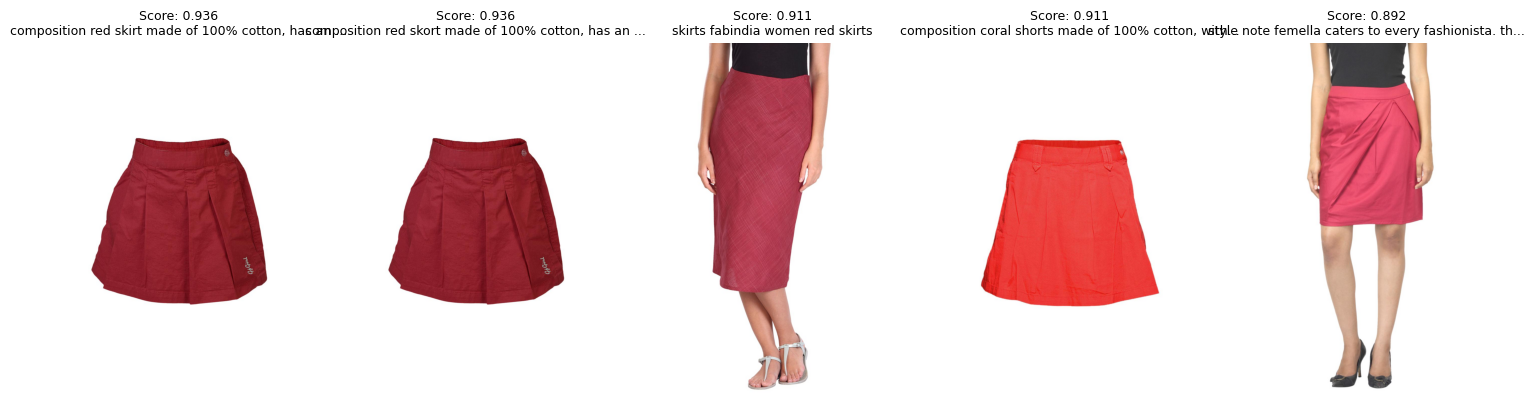


1. Score: 0.9362
   Описание: composition red skirt made of 100% cotton, has an elasticated waistband, two patch pockets on the back, a zipper fly, and brand name embroidered above the left hem in silver fitting regular wash care machine wash separately in cold water using a mild detergent do not bleach or soak line dry inside out in shade warm iron only do not iron directly on printembroidery the cute statement simply zooms high when you dress your little girl in this skort from gini and jony. the shorts and box pleats offer her absolute comfort to move around in ease, while the fabric keeps her fresh and comfortable all day. team this with a t-shirt or girly tops, and sandals, and let your little one play in much comfort.
   Путь: 13305.jpg

2. Score: 0.9362
   Описание: composition red skort made of 100% cotton, has an elasticated waistband, two patch pockets on the back, a zipper fly, and brand name embroidered above the left hem in silver fitting regular wash care machine wash se

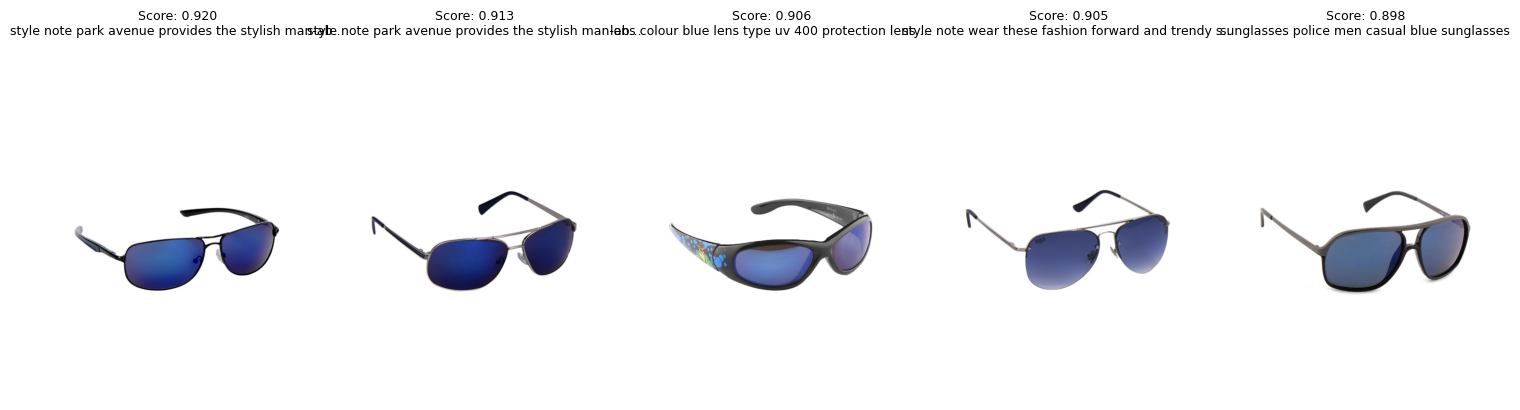


1. Score: 0.9205
   Описание: style note park avenue provides the stylish man-about-town with all the essentials he needs to look his best. wear these park avenue sunglasses to look stylish while out and about in the sunshine. product details lens colour blue lens style tinted frame colour black and blue frame type metal frame with acrylic arms with blue rubber inner provide a comfortable fit and branding on the arms flexible hinges for fit the glasses come in a leather-look case with branding on the front and a zip fastening, cloth included to clean the lenses material and care metal remove dust and grime by gently wiping the lens with the cloth provided rmove oil or tough stains with the help of a lens cleaner and do not use your fingers do not place your glasses on uneven surfaces or heated areas like a dashboard size lens width 65 mm
   Путь: 39995.jpg

2. Score: 0.9129
   Описание: style note park avenue provides the stylish man-about-town with all the essentials he needs to look

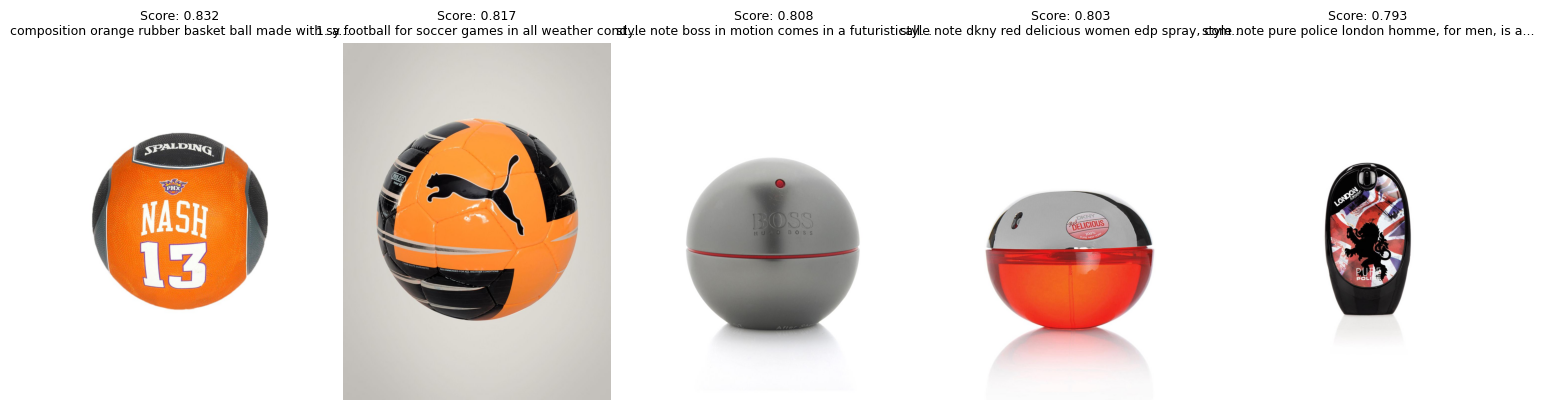


1. Score: 0.8322
   Описание: composition orange rubber basket ball made with synthetic rubber and jersey design care 1. rub surface with clean, damp cloth to remove dust 2. do not machine wash increase your performance level with this nba certified basketball from spalding. the nash no. 13 jersey design on the ball is inspired by basketball legend steve nash - the pulse of the nba. engineered with spalding technology, it is made of a top grade rubber cover and is ideal for outdoor street ball or court games.
   Путь: 4007.jpg

2. Score: 0.8166
   Описание: 1. a football for soccer games in all weather conditions 2. pumas hi-tech airlock valve to keep the ball bouncy at 8-12 psi, 0.6-0.8 bar 3. this fluorescent orange, black and white coloured ball can be spotted effortlessly during night games 4. a size 5 football with 19 cm diameter, it comes with a 1 year shape guarantee all you football fans out there, what are you waiting for lets see you smashing goals out on the field with this

In [169]:
# 18: Тестирование системы поиска

# Тестовые запросы
test_queries = ["red skirt", "blue sunglasses", "mickey mouse"]

for query in test_queries:
    # Выполняем поиск
    results = search_clothing(
        model=model,
        processor=processor,
        image_embeddings=image_embeddings,
        image_paths=image_paths,
        descriptions=descriptions,
        query=query,
        top_k=5
    )
    
    # Отображаем результаты
    display_search_results(results, query)